# P2 EDA — harmonized exploration well outcomes
Non-load-bearing exploration of `wells_primary.parquet` (see
`packages/labels/DATASET_CARD.md` for the decisions and caveats — especially
the BOEM lease-proxy inflation). Counts here are computed from the artifact,
never typed in.

In [1]:
import pandas as pd, matplotlib.pyplot as plt, json
from pathlib import Path
ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
primary = pd.read_parquet(ROOT / "data/parquet/wells_primary.parquet")
summary = json.loads((ROOT / "data/parquet/labels_summary.json").read_text())
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})
len(primary), summary["gate_5000"]

Matplotlib is building the font cache; this may take a moment.


(17329, {'target': 5000, 'primary_actual': 17329, 'met': True})

## Outcomes by source — the BOEM proxy inflation, visible

,n,success
source_id,,
boem_bsee,12444,0.682
nlog,1287,0.470
nsta,2401,0.359
sodir,1197,0.456


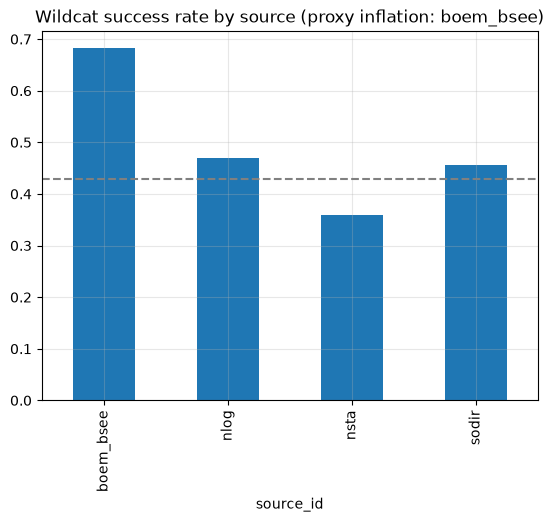

In [2]:
by_src = primary.groupby("source_id").agg(n=("well_id","count"), success=("label","mean")).round(3)
display(by_src)
ax = by_src["success"].plot.bar(title="Wildcat success rate by source (proxy inflation: boem_bsee)")
ax.axhline(by_src.drop(index="boem_bsee")["success"].mean(), ls="--", c="gray"); plt.show()

## Wells and success by decade

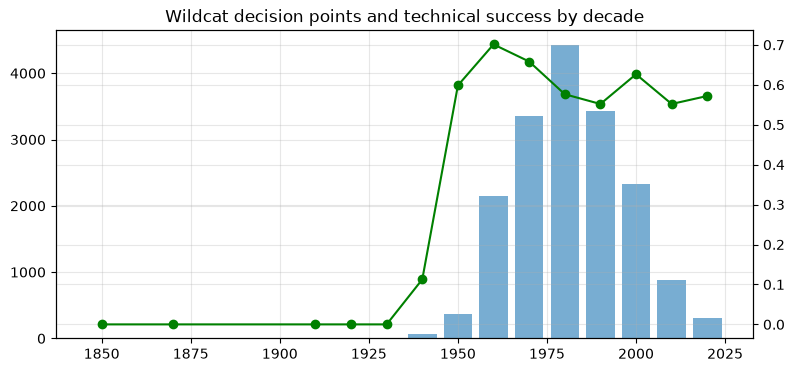

,wildcats,success
decade,,
1850,1,0.000
1870,1,0.000
1910,1,0.000
1920,12,0.000
1930,6,0.000
1940,71,0.113
1950,361,0.598
1960,2151,0.701
1970,3355,0.658


In [3]:
primary["decade"] = (primary["spud_year"] // 10) * 10
dec = primary.groupby("decade").agg(wildcats=("well_id","count"), success=("label","mean"))
fig, ax1 = plt.subplots(figsize=(9,4))
ax1.bar(dec.index, dec["wildcats"], width=8, alpha=0.6, label="wildcats")
ax2 = ax1.twinx(); ax2.plot(dec.index, dec["success"], "g-o", label="success rate")
ax1.set_title("Wildcat decision points and technical success by decade"); plt.show()
dec.round(3)

## Where the wells are

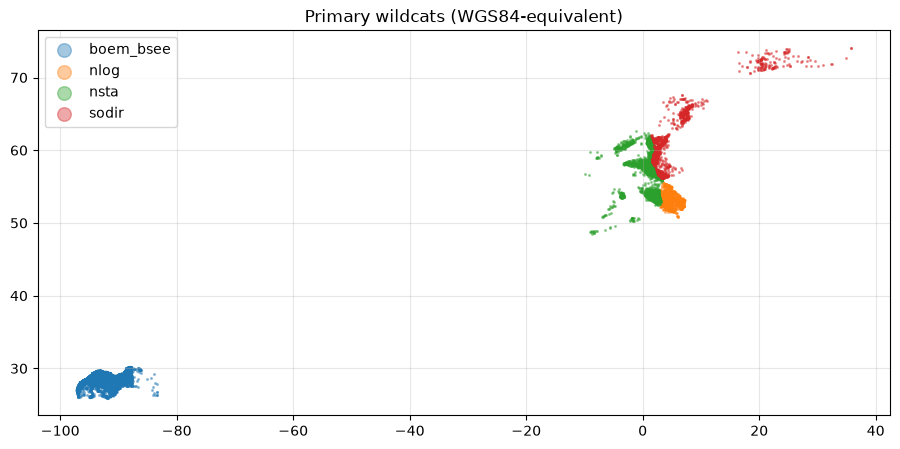

In [4]:
fig, ax = plt.subplots(figsize=(11,5))
for src, g in primary.groupby("source_id"):
    ax.scatter(g["lon"], g["lat"], s=1.5, alpha=0.4, label=src)
ax.legend(markerscale=8); ax.set_title("Primary wildcats (WGS84-equivalent)"); plt.show()

## Count-based creaming curves (volumes await gated GOGET XLSX)

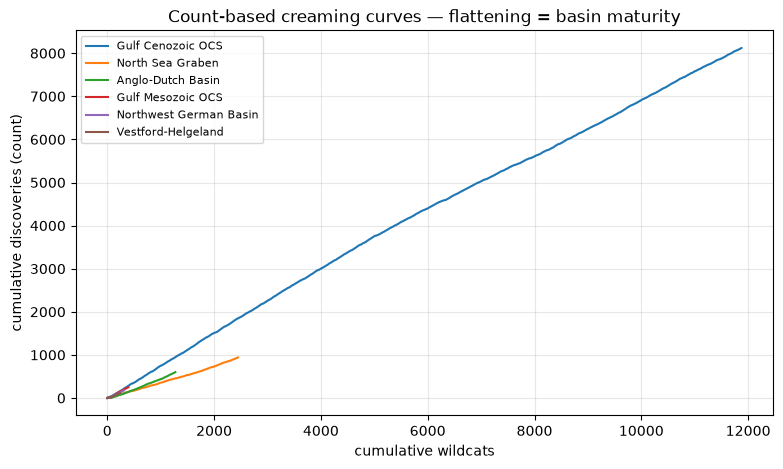

In [5]:
top = primary[primary.province_name != "(unassigned)"].groupby("province_name").size().nlargest(6).index
fig, ax = plt.subplots(figsize=(9,5))
for prov in top:
    g = primary[primary.province_name == prov].sort_values(["spud_year","well_id"])
    ax.plot(range(1, len(g)+1), g["label"].cumsum(), label=prov[:32])
ax.set_xlabel("cumulative wildcats"); ax.set_ylabel("cumulative discoveries (count)")
ax.set_title("Count-based creaming curves — flattening = basin maturity"); ax.legend(fontsize=8); plt.show()

## Honest notes
- BOEM (12,444 wells) uses a lease→field proxy label: 68.2% "success" vs
  35.9–47.0% for true-outcome regulators. `wells_primary_ex_boem.parquet`
  isolates the 4,885 true-outcome wells (41.2%).
- NOPIMS contributes zero labels (no public structured outcomes) — Australia
  is context, not supervision.
- Success = technical discovery, not commercial.